# Example: Spectral-Assisted LAP Tracking Analysis

This notebook demonstrates the spectral-assisted LAP (Linear Assignment Problem) tracker
for linking single-molecule localisations across frames using both spatial proximity
and colour (spectral) information.

**Input:** `.h5` localisation database produced by `SR_Functions.fit_SM_data()` or similar,
containing columns: `frame, xc, yc, s_x, s_y, bg_B, bg_G, bg_R, A_B, A_G, A_R, chi_sqr`
and corresponding error columns.

**Algorithm:** Jaqaman et al. (2008) Nat. Methods 5, 695-702, extended with spectral
distance in normalised RGB space.

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import sys

sys.path.append("../..")

from src import IOFunctions
IO = IOFunctions.IO_Functions()

from src import SM_extractionfunctions
SM_E = SM_extractionfunctions.extract_SMs()

from src import HelperFunctions
H_F = HelperFunctions.Helper_Functions()

from src import PlottingBase
plotter = PlottingBase.PublicationPlotter()

from copy import copy

## 1. Load localisation data

Point `data_folder` at a directory containing `.h5` localisation files
produced by `fit_SM_data()`. Each file should contain one FOV of tracking data.

In [4]:
# --- USER: Set your data path here ---
data_folder = "/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/JSB/20260324_LipidBilayers/AF488ICAM1_AF555CD58_JF646UCHT1"

localisation_files = H_F.file_search(data_folder, ".h5", "")
print(f"Found {len(localisation_files)} localisation file(s)")

Found 31 localisation file(s)


## 2. Quality filter parameters

These are passed to `filter_quality_localisations()` internally.

In [5]:
# Quality filters
chi_val = 2.0
max_localisation_error = 1.5   # pixels
max_colour_error = 0.15
min_photons = 100
max_photons = 1e6

# Linking parameters
max_distance = 10.0    # pixels — maximum spatial jump per frame
max_dark_time = 3     # frames — maximum gap before track is terminated

# Spectral weighting
w_spatial = 1.0       # weight for spatial cost term
w_spectral = 1.0      # weight for spectral cost term
spectral_tol = 0.15   # normalisation scale for spectral distance

## 3. Run spectral LAP linking — all FOVs

Loop over every localisation file, link each independently, tag with the full file path
as `fov_name`, offset `molecular_index` to be globally unique, then concatenate into
combined single-molecule (`sm_db_all`) and single-frame (`sf_db_all`) databases.

In [39]:
all_sm = []
all_sf = []
running_idx_offset = 0
min_frames = 10

for f in localisation_files:
    fov_name = f  # full path as unique FOV identifier
    print(f"Processing: {os.path.basename(f)}")

    loc_data = pd.read_hdf(f)

    sm, sf = SM_E.extract_single_molecules_spectral_lap(
        loc_data.copy(),
        max_distance=max_distance,
        max_dark_time=max_dark_time,
        w_spatial=w_spatial,
        w_spectral=w_spectral,
        spectral_tol=spectral_tol,
        chi_val=chi_val,
        max_localisation_error=max_localisation_error,
        max_colour_error=max_colour_error,
        min_photons=min_photons,
        max_photons=max_photons,
        verbose=False,
    )

    sm = sm[sm['frames'] > min_frames].copy()
    sf = sf[sf['molecular_index'].isin(sm['molecular_index'])].copy()

    sm['molecular_index'] += running_idx_offset
    sf['molecular_index'] += running_idx_offset
    sm['fov_name'] = fov_name
    sf['fov_name'] = fov_name

    running_idx_offset = int(sm['molecular_index'].max()) + 1

    all_sm.append(sm)
    all_sf.append(sf)
    print(f"  -> {len(sm)} molecules")

sm_db = pd.concat(all_sm, ignore_index=True)
sf_db = pd.concat(all_sf, ignore_index=True)

print(f"\nTotal: {len(sm_db)} molecules from {len(localisation_files)} FOVs")

Processing: 4banddichroic_NF_1_MMStack_Default.h5
  -> 39 molecules
Processing: 4banddichroic_NF_2_MMStack_Default.h5
  -> 36 molecules
Processing: 4banddichroic_NF_3_MMStack_Default.h5
  -> 107 molecules
Processing: 4banddichroic_NF_4_MMStack_Default.h5
  -> 92 molecules
Processing: 4banddichroic_NF_5_MMStack_Default.h5
  -> 57 molecules
Processing: 4banddichroic_NF_6_MMStack_Default.h5
  -> 48 molecules
Processing: 4banddichroic_NF_1_MMStack_Default.h5
  -> 29 molecules
Processing: 4banddichroic_NF_2_MMStack_Default.h5
  -> 43 molecules
Processing: 4banddichroic_NF_3_MMStack_Default.h5
  -> 89 molecules
Processing: 4banddichroic_NF_4_MMStack_Default.h5
  -> 55 molecules
Processing: 4banddichroic_NF_5_MMStack_Default.h5
  -> 58 molecules
Processing: 4banddichroic_NF_6_MMStack_Default.h5
  -> 37 molecules
Processing: 4banddichroic_NF_1_MMStack_Default.h5
  -> 35 molecules
Processing: 4banddichroic_NF_2_MMStack_Default.h5
  -> 59 molecules
Processing: 4banddichroic_NF_3_MMStack_Default.

## 4. Inspect the results

/tmp/ipykernel_1059285/243546371.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


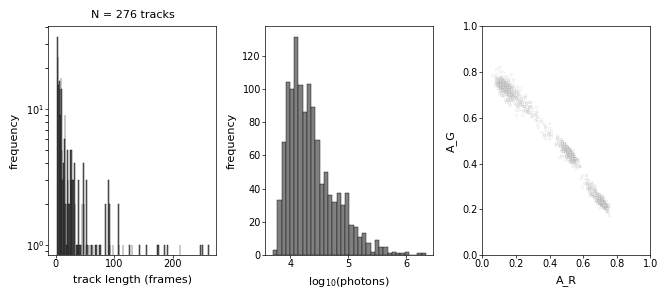

In [40]:
# Track length distribution
track_lengths = sf_db.groupby("molecular_index").size()
track_length = track_lengths[track_lengths > 10]

fig, axs = plotter.two_column_plot(ncols=3)

# Track lengths
bins = np.arange(0.5, track_lengths.max() + 1.5, 1)
axs[0].hist(track_lengths, bins=bins, color="gray", edgecolor="black", linewidth=0.3)
axs[0].set_xlabel("track length (frames)")
axs[0].set_ylabel("frequency")
axs[0].set_yscale('log')
axs[0].set_title(f"N = {len(track_lengths)} tracks")

# Photons per molecule
bins_ph = np.histogram_bin_edges(np.log10(sm_db["photons"].to_numpy()), "sqrt")
axs[1].hist(np.log10(sm_db["photons"]), bins=bins_ph, color="gray", edgecolor="black", linewidth=0.3)
axs[1].set_xlabel(r"log$_{10}$(photons)")
axs[1].set_ylabel("frequency")

# Colour distribution (per molecule)
axs[2].scatter(sm_db["A_R"], sm_db["A_G"], s=3, alpha=0.25, c="white", edgecolors="gray", linewidth=0.3)
axs[2].set_xlabel("A_R")
axs[2].set_ylabel("A_G")
axs[2].set_xlim([0, 1])
axs[2].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('For_Dan.svg', dpi=600, format='svg')
plt.show()

## 5. Visualise trajectories

Plot spatial trajectories coloured by their average RGB values.

/tmp/ipykernel_1059285/281603242.py:24: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


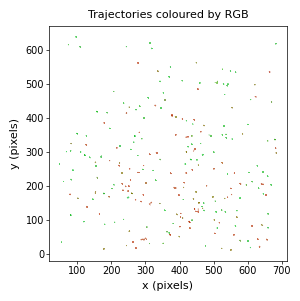

In [38]:
fig, ax = plotter.create_figure(figsize=(3, 3))

for mol_idx in np.unique(sm_db["molecular_index"].values):
    track = sf_db[sf_db["molecular_index"] == mol_idx].sort_values("frame")
    if len(track) < 11:
        continue

    # Use track colour as line colour
    r = track["A_R"].mean()
    g = track["A_G"].mean()
    b = track["A_B"].mean()
    total = r + g + b
    if total > 0:
        color = np.clip([r / total, g / total, b / total], 0, 1)
    else:
        color = [0.5, 0.5, 0.5]

    ax.plot(track["xc"], track["yc"], lw=0.5, alpha=0.7, color=color)

ax.set_xlabel("x (pixels)")
ax.set_ylabel("y (pixels)")
ax.set_aspect("equal")
ax.set_title("Trajectories coloured by RGB")
plt.tight_layout()
plt.show()

## 6. Compare with greedy nearest-neighbour linking

Run the standard (non-spectral) linker for comparison.

In [26]:
sm_db_nn, sf_db_nn = SM_E.extract_single_molecules_linked(
    loc_data.copy(),
    max_distance=max_distance,
    chi_val=chi_val,
    max_localisation_error=max_localisation_error,
    max_colour_error=max_colour_error,
    min_photons=min_photons,
    max_photons=max_photons,
)

print(f"Greedy NN:     {len(sm_db_nn)} molecules from {len(sf_db_nn)} localisations")
print(f"Spectral LAP:  {len(sm_db)} molecules from {len(sf_db)} localisations")

Greedy NN:     30637 molecules from 74023 localisations
Spectral LAP:  38206 molecules from 74023 localisations


In [ ]:
# Compare track length distributions
track_lengths_nn = sf_db_nn.groupby("molecular_index").size()
track_lengths_lap = sf_db.groupby("molecular_index").size()

fig, axs = plotter.create_subplots(ncols=2, figsize=(10, 4))

max_len = max(track_lengths_nn.max(), track_lengths_lap.max())
bins = np.arange(0.5, max_len + 1.5, 1)

axs[0].hist(track_lengths_nn, bins=bins, color="gray", edgecolor="black",
            linewidth=0.3, alpha=0.7, label=f"NN (N={len(track_lengths_nn)})")
axs[0].hist(track_lengths_lap, bins=bins, color="steelblue", edgecolor="black",
            linewidth=0.3, alpha=0.7, label=f"LAP (N={len(track_lengths_lap)})")
axs[0].set_xlabel("track length (frames)")
axs[0].set_ylabel("frequency")
axs[0].legend()

# Compare colour purity per track (std of A_R within each track)
colour_std_nn = sf_db_nn.groupby("molecular_index")["A_R"].std().dropna()
colour_std_lap = sf_db.groupby("molecular_index")["A_R"].std().dropna()

bins_std = np.linspace(0, 0.3, 50)
axs[1].hist(colour_std_nn, bins=bins_std, color="gray", edgecolor="black",
            linewidth=0.3, alpha=0.7, density=True, label="NN")
axs[1].hist(colour_std_lap, bins=bins_std, color="steelblue", edgecolor="black",
            linewidth=0.3, alpha=0.7, density=True, label="Spectral LAP")
axs[1].set_xlabel("intra-track std(A_R)")
axs[1].set_ylabel("density")
axs[1].set_title("Spectral consistency within tracks")
axs[1].legend()

plt.tight_layout()
plt.show()

print(f"\nMedian intra-track std(A_R):")
print(f"  Greedy NN:     {colour_std_nn.median():.4f}")
print(f"  Spectral LAP:  {colour_std_lap.median():.4f}")

## 7. Mean Squared Displacement (MSD) analysis

Compute and plot the ensemble-averaged MSD from the tracked molecules.

In [ ]:
def compute_msd(track_df, pixel_size_nm=69.0, frame_time_s=0.1, max_lag=20):
    """Compute MSD for a single track."""
    track = track_df.sort_values("frame")
    x = track["xc"].to_numpy() * pixel_size_nm
    y = track["yc"].to_numpy() * pixel_size_nm
    frames = track["frame"].to_numpy().astype(int)

    msd_vals = []
    msd_lags = []

    for lag in range(1, min(max_lag + 1, len(track))):
        dx = x[lag:] - x[:-lag]
        dy = y[lag:] - y[:-lag]
        dframes = frames[lag:] - frames[:-lag]

        # Only include pairs where the frame gap matches the lag
        valid = dframes == lag
        if valid.sum() > 0:
            sq_disp = dx[valid] ** 2 + dy[valid] ** 2
            msd_vals.append(np.mean(sq_disp))
            msd_lags.append(lag * frame_time_s)

    return np.array(msd_lags), np.array(msd_vals)

In [ ]:
# --- USER: set pixel size and frame time ---
pixel_size_nm = 69.0   # nm per pixel
frame_time_s = 0.1     # seconds per frame
max_lag = 20           # maximum lag in frames
min_track_length = 5   # minimum track length to include in MSD

# Collect MSD from all tracks
all_msd = {}
for mol_idx in sm_db["molecular_index"].values:
    track = sf_db[sf_db["molecular_index"] == mol_idx]
    if len(track) < min_track_length:
        continue
    lags, msd = compute_msd(track, pixel_size_nm, frame_time_s, max_lag)
    for l, m in zip(lags, msd):
        all_msd.setdefault(l, []).append(m)

# Ensemble average
lags_sorted = np.array(sorted(all_msd.keys()))
msd_mean = np.array([np.mean(all_msd[l]) for l in lags_sorted])
msd_sem = np.array([np.std(all_msd[l]) / np.sqrt(len(all_msd[l])) for l in lags_sorted])

fig, ax = plotter.create_figure(figsize=(5, 4))
ax.errorbar(lags_sorted, msd_mean, yerr=msd_sem, fmt="o-", markersize=4, capsize=2)
ax.set_xlabel("lag time (s)")
ax.set_ylabel(r"MSD (nm$^2$)")
ax.set_title("Ensemble-averaged MSD")

# Fit first 4 points for D estimate
n_fit = min(4, len(lags_sorted))
if n_fit >= 2:
    coeffs = np.polyfit(lags_sorted[:n_fit], msd_mean[:n_fit], 1)
    D = coeffs[0] / 4  # 2D diffusion: MSD = 4Dt
    ax.plot(lags_sorted[:n_fit], np.polyval(coeffs, lags_sorted[:n_fit]),
            "r--", label=f"D = {D:.1f} nm$^2$/s")
    ax.legend()

plt.tight_layout()
plt.show()

## 8. Save results

In [ ]:
# Save combined single-molecule and single-frame databases
output_folder = data_folder

sm_db.to_hdf(
    os.path.join(output_folder, "spectral_lap_single_molecules.h5"),
    key="data", format="table",
)
sf_db.to_hdf(
    os.path.join(output_folder, "spectral_lap_single_frames.h5"),
    key="data", format="table",
)

print(f"Saved to {output_folder}")
print(f"  spectral_lap_single_molecules.h5  ({len(sm_db)} molecules from {sm_db['fov_name'].nunique()} FOVs)")
print(f"  spectral_lap_single_frames.h5     ({len(sf_db)} localisations)")